# How this notebook is laid out - Decision Tree for Warehouse hazard Prediction

1) First load required packages (including pandas and scikitlearn)
2) Generate Dataset (run once)
3) Train a Decision Tree Classifier
4) Plot Training vs Cross-Validation Accuracy


In [9]:
# Verify required packages are available
import sys
print(f"Python version: {sys.version}")

try:
    import numpy as np
    print(f"✓ numpy {np.__version__} is available")
except ImportError as e:
    print(f"✗ numpy not available: {e}")

try:
    import pandas as pd
    print(f"✓ pandas {pd.__version__} is available")
except ImportError as e:
    print(f"✗ pandas not available: {e}")

try:
    import matplotlib.pyplot as plt
    print("✓ matplotlib is available")
except ImportError as e:
    print(f"✗ matplotlib not available: {e}")

try:
    import sklearn
    print(f"✓ scikit-learn {sklearn.__version__} is available")
except ImportError as e:
    print(f"✗ scikit-learn not available: {e}")
    print("Installing scikit-learn...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--break-system-packages", "scikit-learn"])

print("All required packages are ready!")

Python version: 3.12.13 (main, Mar  3 2026, 12:39:30) [Clang 17.0.0 (clang-1700.6.3.2)]
✓ numpy 2.4.1 is available
✓ pandas 3.0.1 is available
✓ matplotlib is available
✓ scikit-learn 1.8.0 is available
All required packages are ready!


# Generate dataset (Run once)

Dataset: Generate warehouse_hazard.csv from the code below. The features are:

| Feature            | Description                                 | Range    |
|--------------------|---------------------------------------------|----------|
| `load_kg`          | Weight stored at the location (kg)          | 100–1000 |
| `inspection_days`  | Days since last inspection                  | 1–90     |
| `sensors`          | Number of active monitoring sensors         | 1–5      |
| `floor_age_years`  | Age of the floor section (years)            | 1–30     |

The label is high_risk (1 = incident occurred, 0 = no incident).

In [6]:
import numpy as np
import pandas as pd
np.random.seed(42)
n = 300
load = np.random.randint(100, 1001, n)
inspection = np.random.randint(1, 91, n)
sensors = np.random.randint(1, 6, n)
floor_age = np.random.randint(1, 31, n)
# True risk rule (unknown to the student): high risk when
# load > 500 OR inspection > 45.  Label noise (~20%) simulates
# real-world measurement error.
true_risk = ((load > 500) | (inspection > 45)).astype(float)
flip = np.random.random(n) < 0.20
high_risk = true_risk.copy()
high_risk[flip] = 1 - high_risk[flip]
high_risk = high_risk.astype(int)
df = pd.DataFrame({
    "load_kg": load, "inspection_days": inspection,
    "sensors": sensors, "floor_age_years": floor_age,
    "high_risk": high_risk,
})
df.to_csv("warehouse_hazard.csv", index=False)
print(df.head(10))
print(f"\nClass balance: {high_risk.sum()} high-risk, "
      f"{n - high_risk.sum()} low-risk out of {n}")

   load_kg  inspection_days  sensors  floor_age_years  high_risk
0      202               59        5               29          1
1      535               70        4               20          1
2      960               80        1               15          1
3      370                3        5               15          0
4      206               20        1               24          0
5      171               59        3               22          1
6      800               36        1               14          0
7      120               19        1               26          0
8      714               90        1               28          1
9      221               67        4               23          1

Class balance: 189 high-risk, 111 low-risk out of 300


# Decision Trees: Entropy and Information Gain

---

## Tasks

### 1. Information Gain (by hand)

Consider splitting the root node on:

- **Candidate Split A:** `load_kg >= 500`
- **Candidate Split B:** `sensors <= 2`

Write a simple script to determine the number of **high-risk (p)** and **low-risk (¬p)** samples in each case.

For **each candidate split**, do the following:

- Compute the **entropy of the full dataset**
- Compute the **entropy of each child node** after the split
- Compute the **information gain**
- Determine **which split is better**, and explain **why**

> **Instructions**
>
> - Show **all calculations**
> - Use the formula from **Section 5.1.10: Entropy and Information Gain**

---

#### Entropy

\[
H(S) = - \sum_i p_i \log_2(p_i)
\]

#### Information Gain

\[
IG(S, A) = H(S) - \sum_v \frac{|S_v|}{|S|} H(S_v)
\]

---

### 2. Build the First Two Levels of the Tree

Starting from the **better root split** identified above:

- Use the **other candidate split** for the **second level** in **both child nodes**
- Draw the resulting decision tree:
  - **3 internal nodes**
  - **4 leaf nodes**

Then answer:

- What is the **training accuracy** of this two-level tree?

> **Note**
>
> A real decision tree algorithm would evaluate *all features and thresholds* at each node to find the maximum information gain.  
> Here, we restrict ourselves to the **two given candidate splits** to keep the hand calculation tractable.

---

### 3. Implementation with scikit-learn

Train a decision tree classifier using **entropy** as the splitting criterion.

```python
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score

In [8]:
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score

# Prepare features and target
X = df[["load_kg", "inspection_days", "sensors", "floor_age_years"]]
y = df["high_risk"]

# Train DecisionTreeClassifier with entropy criterion
dt = DecisionTreeClassifier(criterion="entropy", random_state=42)
dt.fit(X, y)

# Print the tree structure
tree_rules = export_text(dt, feature_names=list(X.columns))
print("Decision Tree Structure:")
print(tree_rules)

# Compute training accuracy
y_pred = dt.predict(X)
accuracy = accuracy_score(y, y_pred)
print(f"\nTraining Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Decision Tree Structure:
|--- load_kg <= 500.50
|   |--- inspection_days <= 46.50
|   |   |--- inspection_days <= 16.50
|   |   |   |--- class: 0
|   |   |--- inspection_days >  16.50
|   |   |   |--- load_kg <= 117.00
|   |   |   |   |--- inspection_days <= 36.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- inspection_days >  36.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- load_kg >  117.00
|   |   |   |   |--- inspection_days <= 18.00
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- inspection_days >  18.00
|   |   |   |   |   |--- inspection_days <= 23.50
|   |   |   |   |   |   |--- load_kg <= 302.50
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- load_kg >  302.50
|   |   |   |   |   |   |   |--- floor_age_years <= 22.00
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- floor_age_years >  22.00
|   |   |   |   |   |   |   |   |--- load_kg <= 309.50
|   |   |   |   |   |   |   |   |   |--- class: 1
|   |  

## 4. Overfitting Analysis

For the following values of `max_depth`:

\[
\{1, 2, 3, 4, 5, 6, \text{None}\}
\]

perform the steps below.

---

### Tasks

- Compute the **training accuracy** for each value of `max_depth`
- Compute the **5-fold cross-validation accuracy** for each value of `max_depth`
- Plot **both curves on the same axes**
  - **x-axis:** `max_depth`
  - **y-axis:** accuracy

---

### Analysis Question

- **At what depth does overfitting begin?**
- **How do you know?**

Explain your reasoning by comparing the training accuracy curve with the cross-validation accuracy curve.

---

## Copilot Hint (Comment 5.15)

> **Prompt**
>
> *Loop over `max_depth` values, compute training accuracy and `cross_val_score` for each, and plot both curves with matplotlib.*

---

## Notes

- Use **code cells** for:
  - Model training
  - Cross-validation
  - Plotting
- Use **Markdown cells** for:
  - Interpretation
  - Discussion of overfitting behavior
- Clearly label axes, legends, and titles in plots

---

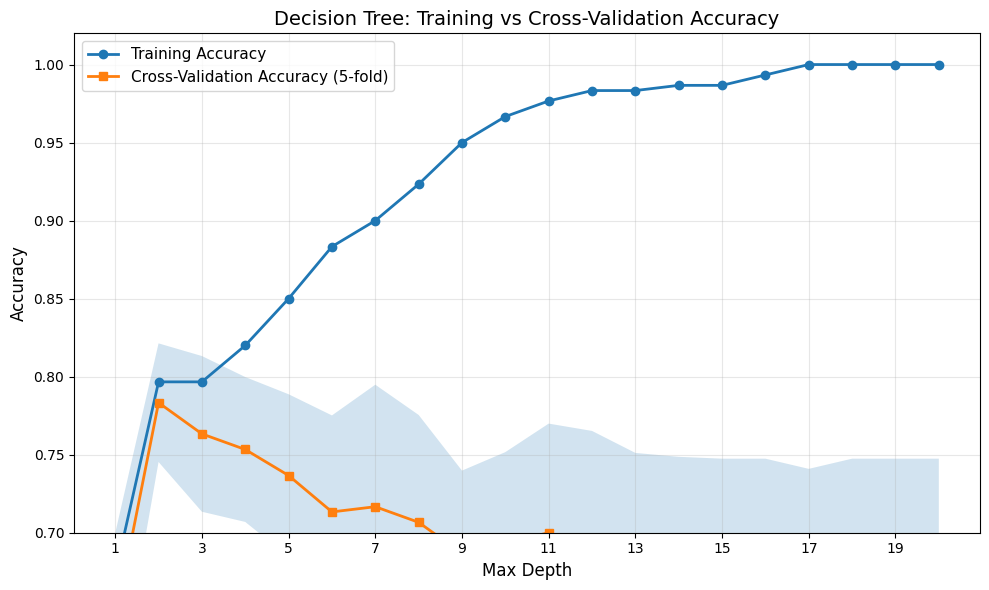

Max Depth | Training Acc | CV Acc (mean ± std)
--------------------------------------------------
 1       | 0.6733       | 0.6433 ± 0.0564
 2       | 0.7967       | 0.7833 ± 0.0380
 3       | 0.7967       | 0.7633 ± 0.0499
 4       | 0.8200       | 0.7533 ± 0.0464
 5       | 0.8500       | 0.7367 ± 0.0521
 6       | 0.8833       | 0.7133 ± 0.0618
 7       | 0.9000       | 0.7167 ± 0.0782
 8       | 0.9233       | 0.7067 ± 0.0688
 9       | 0.9500       | 0.6867 ± 0.0531
10       | 0.9667       | 0.6933 ± 0.0583
11       | 0.9767       | 0.7000 ± 0.0699
12       | 0.9833       | 0.6767 ± 0.0886
13       | 0.9833       | 0.6867 ± 0.0645
14       | 0.9867       | 0.6800 ± 0.0686
15       | 0.9867       | 0.6833 ± 0.0641
16       | 0.9933       | 0.6833 ± 0.0641
17       | 1.0000       | 0.6800 ± 0.0609
18       | 1.0000       | 0.6833 ± 0.0641
19       | 1.0000       | 0.6833 ± 0.0641
20       | 1.0000       | 0.6833 ± 0.0641


In [10]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# Test max_depth values
max_depths = range(1, 21)
train_accuracies = []
cv_scores_mean = []
cv_scores_std = []

for depth in max_depths:
    # Train model with current depth
    dt = DecisionTreeClassifier(criterion="entropy", max_depth=depth, random_state=42)
    dt.fit(X, y)
    
    # Compute training accuracy
    train_acc = dt.score(X, y)
    train_accuracies.append(train_acc)
    
    # Compute cross-validation scores (5-fold CV)
    cv_scores = cross_val_score(dt, X, y, cv=5, scoring='accuracy')
    cv_scores_mean.append(cv_scores.mean())
    cv_scores_std.append(cv_scores.std())

# Plot both curves
plt.figure(figsize=(10, 6))
plt.plot(max_depths, train_accuracies, 'o-', label='Training Accuracy', linewidth=2, markersize=6)
plt.plot(max_depths, cv_scores_mean, 's-', label='Cross-Validation Accuracy (5-fold)', linewidth=2, markersize=6)
plt.fill_between(max_depths, 
                 [m - s for m, s in zip(cv_scores_mean, cv_scores_std)],
                 [m + s for m, s in zip(cv_scores_mean, cv_scores_std)],
                 alpha=0.2)
plt.xlabel('Max Depth', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Decision Tree: Training vs Cross-Validation Accuracy', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 21, 2))
plt.ylim([0.7, 1.02])
plt.tight_layout()
plt.show()

# Print summary
print("Max Depth | Training Acc | CV Acc (mean ± std)")
print("-" * 50)
for depth, train_acc, cv_mean, cv_std in zip(max_depths, train_accuracies, cv_scores_mean, cv_scores_std):
    print(f"{depth:2d}       | {train_acc:.4f}       | {cv_mean:.4f} ± {cv_std:.4f}")